#  House Price Prediction

we want to predict the market value of residential properties based on historical data.
The goal is to identify key features—like square footage, number of rooms, location, and so forth—that drive pricing, so that we can automate estimates for new listings.
Now, for the dataset, I assume you have a structured dataset with these features and corresponding prices.


## 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

## 2. Loading the Dataset
 

In [2]:
df = pd.read_csv("dataset/HousePricePrediction.csv")

df.head()

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


## 3. Exploratory Data Analysis (EDA)

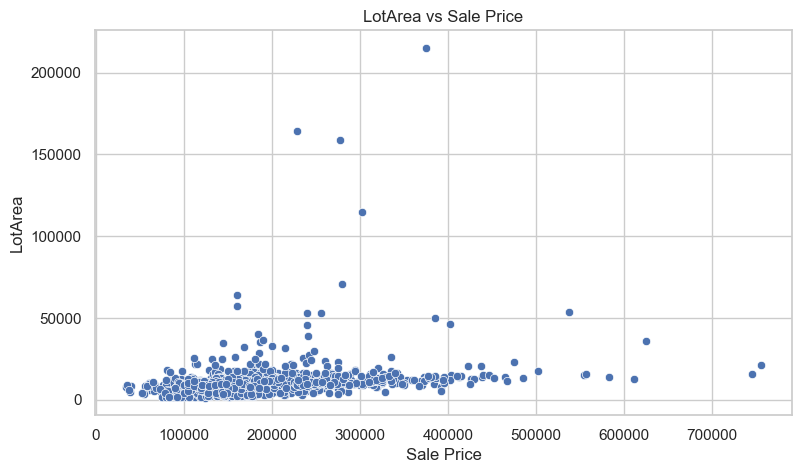

In [4]:
plt.figure(figsize=(9, 5))
sns.scatterplot(x="SalePrice", y="LotArea", data=df)
plt.title("LotArea vs Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("LotArea")
plt.show()

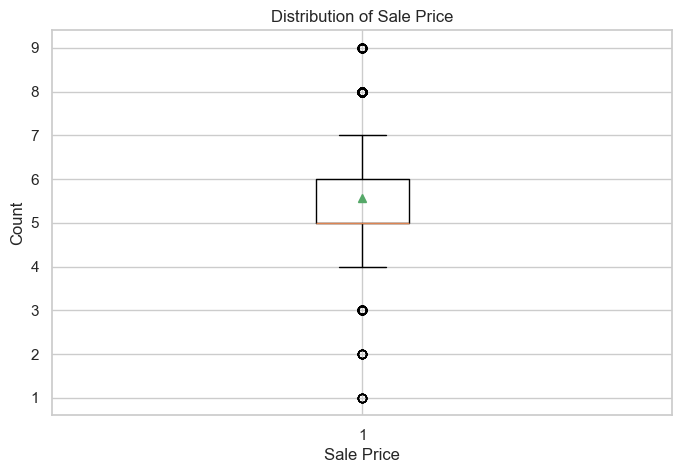

In [5]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["OverallCond"],showmeans=True)
plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

### Box Plot for Outlier Detection


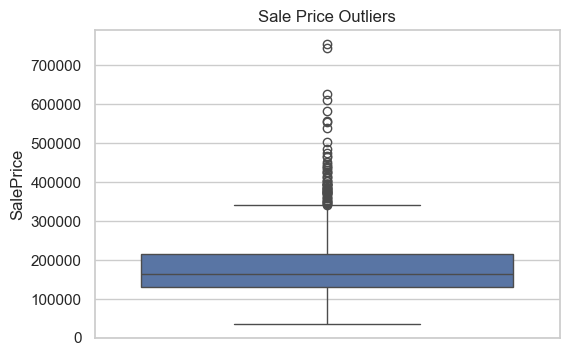

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["SalePrice"])
plt.title("Sale Price Outliers")
plt.show()


### Total Basement Area vs Sale Price


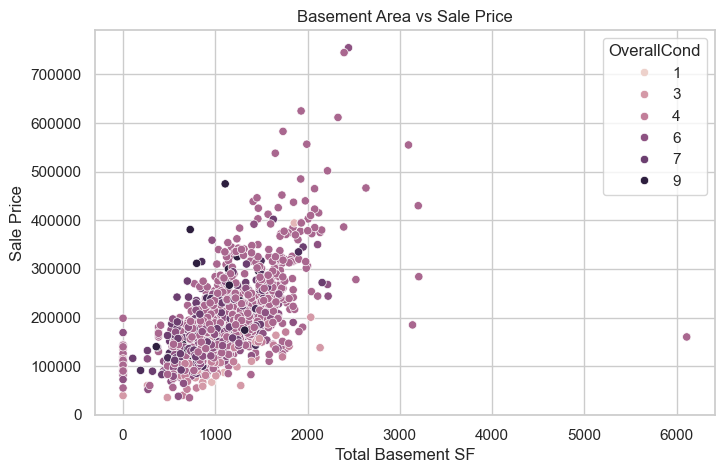

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["TotalBsmtSF"],
    y=df["SalePrice"],
    hue=df["OverallCond"]
)
plt.title("Basement Area vs Sale Price")
plt.xlabel("Total Basement SF")
plt.ylabel("Sale Price")
plt.show()

### Living Area vs Sale Price


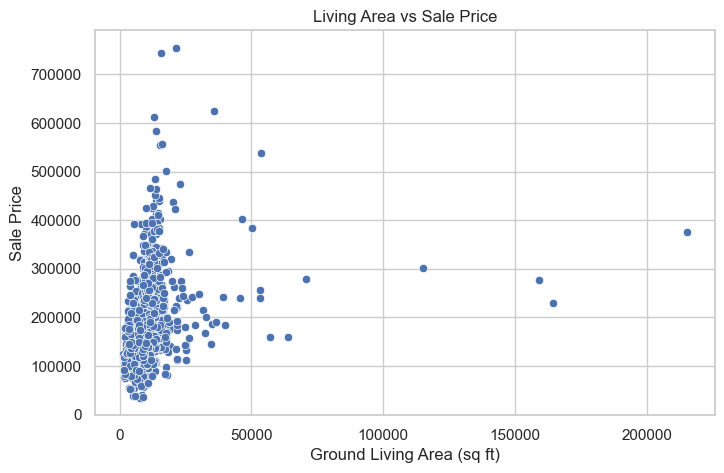

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=df["LotArea"],
    y=df["SalePrice"]
)
plt.title("Living Area vs Sale Price")
plt.xlabel("Ground Living Area (sq ft)")
plt.ylabel("Sale Price")
plt.show()

## 4. Data Cleaning

In [9]:
isnull_counts = df.isnull().sum()

isnull_counts

Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [10]:
#dropping Irrelevant or High-NaN Columns
df = df.drop("Id", axis=1)

#dropping Rows with Missing Target Values
df = df.dropna(subset=["SalePrice"])

## 5. Feature and Target Separation

In [11]:
category_var = df.select_dtypes(include = 'object')
num_var = df.select_dtypes(exclude = 'object')

print("Number of categorical features are: ", category_var.shape[1])
print("Number of numerical features are: ", num_var.shape[1])

Number of categorical features are:  4
Number of numerical features are:  8


In [12]:
X = df.drop("SalePrice", axis=1)
Y = df["SalePrice"]

## 6. Feature Encoding


In [13]:
#One-hot encode categorical features

cat_cols = X.select_dtypes(include=["object"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#Convert boolean columns to integers

bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

X


,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,MSZoning_FV,MSZoning_RH,MSZoning_RL,...,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing
0,60,8450,5,2003,2003,0.0,856.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1,20,9600,8,1976,1976,0.0,1262.0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
2,60,11250,5,2001,2002,0.0,920.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,70,9550,5,1915,1970,0.0,756.0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,60,14260,5,2000,2000,0.0,1145.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,7917,5,1999,2000,0.0,953.0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
1456,20,13175,6,1978,1988,163.0,1542.0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1457,70,9042,9,1941,2006,0.0,1152.0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
1458,20,9717,6,1950,1996,1029.0,1078.0,0,0,1,...,0,0,0,1,0,0,0,0,0,0


## 7. Train-Test Split


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42
)

## 8. Model Training and Evaluation


In [15]:
#Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

Y_pred_lr = lr_model.predict(X_test)
r2_lr = r2_score(Y_test, Y_pred_lr)

r2_lr

0.6195131796544855

### Lasso Regression (L1 Regularization)


In [16]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train_scaled, Y_train)

# Predict
Y_pred_lasso = lasso_model.predict(X_test_scaled)

# Evaluate
r2_lasso = r2_score(Y_test, Y_pred_lasso)

r2_lasso

0.6195131733146326

### Ridge Regression (L2 Regularization)


In [17]:
from sklearn.linear_model import Ridge


ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, Y_train)

Y_pred_ridge = ridge_model.predict(X_test_scaled)
r2_ridge = r2_score(Y_test, Y_pred_ridge)

r2_ridge

0.6194969160971621

### RandomForest Regression

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train_scaled, Y_train)

Y_pred_rf = rf.predict(X_test_scaled)

r2_rf = r2_score(Y_test, Y_pred_rf)
r2_rf

0.822615524066765

### XGB Regression

In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300, learning_rate=0.05)
xgb.fit(X_train_scaled, Y_train)
Y_pred_xgb = xgb.predict(X_test_scaled)
r2_xgb = r2_score(Y_test, Y_pred_xgb)
r2_xgb

0.826412112847122

## 9. Model Performance Comparison

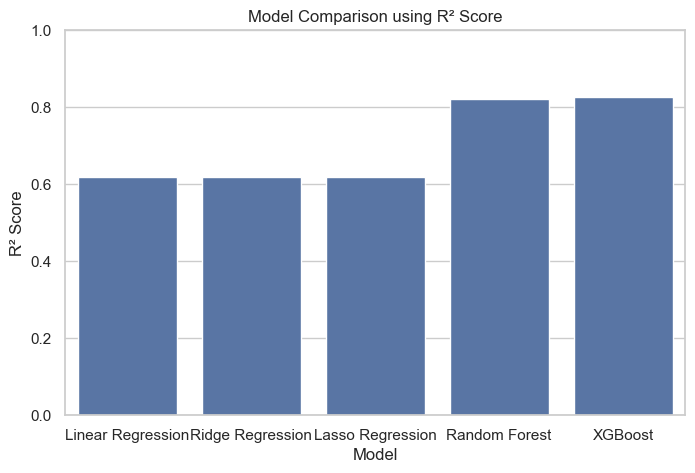

In [20]:
#R² Score Comparison Table

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression", "Random Forest", "XGBoost"],
    "R2 Score": [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_xgb]
})

results_df

#R² Score Comparison Visualization

plt.figure(figsize=(8, 5))
sns.barplot(
    x="Model",
    y="R2 Score",
    data=results_df
)
plt.title("Model Comparison using R² Score")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

# 10. Saving model 

In [21]:
import pickle

# Save the baseline trained model to a file
with open("models/lr_model.pkl", "wb") as file:  #
    pickle.dump(lr_model, file)


# Save the Ridge trained model to a file
with open("models/ridge_model.pkl", "wb") as file:  #
    pickle.dump(ridge_model, file)

# Save the lasso trained model to a file
with open("models/lasso_model.pkl", "wb") as file:  #
    pickle.dump(lasso_model, file)

# 11. Saving the Package Version

In [22]:
import pkg_resources

# List of the packages you know you're using
required_packages = [
    'numpy',
    'pandas',
    'scikit-learn',
    'matplotlib',
    'seaborn',
    'ipykernel',
]

requirements = []

for package in required_packages:
    try:
        version = pkg_resources.get_distribution(package).version
        requirements.append(f"{package}=={version}")
    except pkg_resources.DistributionNotFound:
        print(f"Package {package} not found in the environment.")

#requirements to a file
with open('requirements.txt', 'w') as f:
    for line in requirements:
        f.write(line + '\n')

/var/folders/s3/7_ps073573349p4rwxh_fxzr0000gn/T/ipykernel_20933/116971148.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
